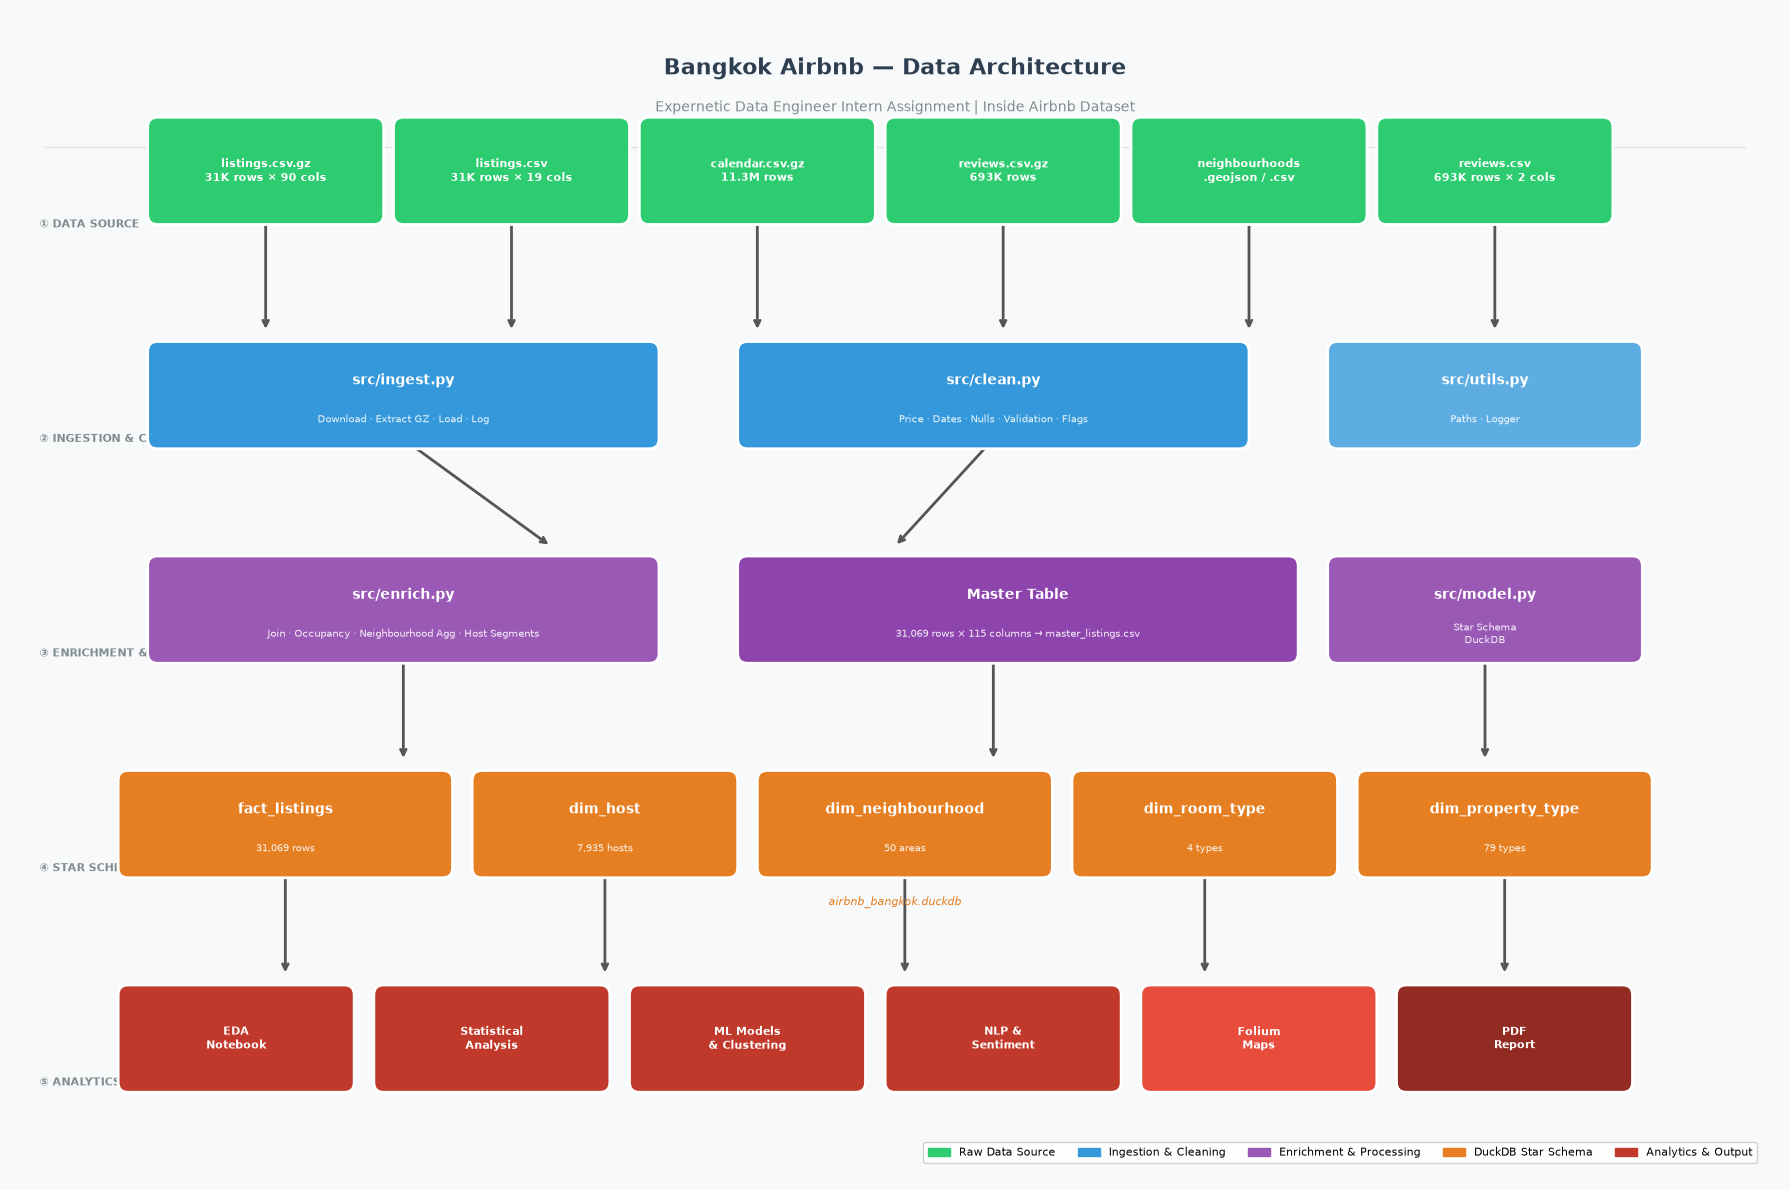

✓ Architecture diagram saved to reports/architecture_diagram.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

fig, ax = plt.subplots(1, 1, figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 12)
ax.axis("off")
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

def draw_box(ax, x, y, w, h, label, sublabel="", color="#4C72B0", text_color="white", fontsize=10):
    box = FancyBboxPatch((x, y), w, h,
                         boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor="white",
                         linewidth=2, zorder=3)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0),
            label, ha="center", va="center",
            color=text_color, fontsize=fontsize,
            fontweight="bold", zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25,
                sublabel, ha="center", va="center",
                color=text_color, fontsize=7.5,
                alpha=0.9, zorder=4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="#555555",
                                lw=2.0, connectionstyle="arc3,rad=0.0"),
                zorder=2)

# ── Title ──
ax.text(9, 11.4, "Bangkok Airbnb — Data Architecture",
        ha="center", va="center", fontsize=16,
        fontweight="bold", color="#2C3E50")
ax.text(9, 11.0, "Expernetic Data Engineer Intern Assignment | Inside Airbnb Dataset",
        ha="center", va="center", fontsize=10, color="#7F8C8D")

# ── Layer Labels ──
for y, label in [(9.8, "① DATA SOURCE"),
                 (7.6, "② INGESTION & CLEANING"),
                 (5.4, "③ ENRICHMENT & PROCESSING"),
                 (3.2, "④ STAR SCHEMA — DuckDB"),
                 (1.0, "⑤ ANALYTICS & OUTPUT")]:
    ax.text(0.3, y, label, ha="left", va="center",
            fontsize=8, color="#7F8C8D", fontweight="bold")

ax.axhline(y=10.6, xmin=0.02, xmax=0.98, color="#DEE2E6", linewidth=1)

# ── Layer 1: Data Source ──
sources = [
    ("listings.csv.gz\n31K rows × 90 cols", 1.5),
    ("listings.csv\n31K rows × 19 cols", 4.0),
    ("calendar.csv.gz\n11.3M rows", 6.5),
    ("reviews.csv.gz\n693K rows", 9.0),
    ("neighbourhoods\n.geojson / .csv", 11.5),
    ("reviews.csv\n693K rows × 2 cols", 14.0),
]
for label, x in sources:
    draw_box(ax, x, 9.9, 2.2, 0.9, label, color="#2ECC71", fontsize=8)
    draw_arrow(ax, x+1.1, 9.9, x+1.1, 8.7)

# ── Layer 2: Ingestion & Cleaning ──
draw_box(ax, 1.5, 7.6, 5.0, 0.9,
         "src/ingest.py",
         "Download · Extract GZ · Load · Log",
         color="#3498DB")
draw_box(ax, 7.5, 7.6, 5.0, 0.9,
         "src/clean.py",
         "Price · Dates · Nulls · Validation · Flags",
         color="#3498DB")
draw_box(ax, 13.5, 7.6, 3.0, 0.9,
         "src/utils.py",
         "Paths · Logger",
         color="#5DADE2")

draw_arrow(ax, 4.0, 7.6, 5.5, 6.5)
draw_arrow(ax, 10.0, 7.6, 9.0, 6.5)

# ── Layer 3: Enrichment ──
draw_box(ax, 1.5, 5.4, 5.0, 0.9,
         "src/enrich.py",
         "Join · Occupancy · Neighbourhood Agg · Host Segments",
         color="#9B59B6")
draw_box(ax, 7.5, 5.4, 5.5, 0.9,
         "Master Table",
         "31,069 rows × 115 columns → master_listings.csv",
         color="#8E44AD")
draw_box(ax, 13.5, 5.4, 3.0, 0.9,
         "src/model.py",
         "Star Schema\nDuckDB",
         color="#9B59B6")

draw_arrow(ax, 4.0, 5.4, 4.0, 4.3)
draw_arrow(ax, 10.0, 5.4, 10.0, 4.3)
draw_arrow(ax, 15.0, 5.4, 15.0, 4.3)

# ── Layer 4: DuckDB Star Schema ──
draw_box(ax, 1.2, 3.2, 3.2, 0.9,
         "fact_listings",
         "31,069 rows",
         color="#E67E22")
draw_box(ax, 4.8, 3.2, 2.5, 0.9,
         "dim_host",
         "7,935 hosts",
         color="#E67E22")
draw_box(ax, 7.7, 3.2, 2.8, 0.9,
         "dim_neighbourhood",
         "50 areas",
         color="#E67E22")
draw_box(ax, 10.9, 3.2, 2.5, 0.9,
         "dim_room_type",
         "4 types",
         color="#E67E22")
draw_box(ax, 13.8, 3.2, 2.8, 0.9,
         "dim_property_type",
         "79 types",
         color="#E67E22")

ax.text(9, 2.85, "airbnb_bangkok.duckdb",
        ha="center", va="center", fontsize=8,
        color="#E67E22", fontstyle="italic")

for x in [2.8, 6.05, 9.1, 12.15, 15.2]:
    draw_arrow(ax, x, 3.2, x, 2.1)

# ── Layer 5: Output ──
outputs = [
    ("EDA\nNotebook", "#C0392B", 1.2),
    ("Statistical\nAnalysis", "#C0392B", 3.8),
    ("ML Models\n& Clustering", "#C0392B", 6.4),
    ("NLP &\nSentiment", "#C0392B", 9.0),
    ("Folium\nMaps", "#E74C3C", 11.6),
    ("PDF\nReport", "#922B21", 14.2),
]
for label, color, x in outputs:
    draw_box(ax, x, 1.0, 2.2, 0.9, label, color=color, fontsize=8)

# ── Legend ──
legend_items = [
    mpatches.Patch(color="#2ECC71", label="Raw Data Source"),
    mpatches.Patch(color="#3498DB", label="Ingestion & Cleaning"),
    mpatches.Patch(color="#9B59B6", label="Enrichment & Processing"),
    mpatches.Patch(color="#E67E22", label="DuckDB Star Schema"),
    mpatches.Patch(color="#C0392B", label="Analytics & Output"),
]
ax.legend(handles=legend_items, loc="lower right",
          fontsize=8, framealpha=0.9, ncol=5,
          bbox_to_anchor=(0.99, 0.01))

plt.tight_layout()
plt.savefig("../reports/architecture_diagram.png",
            bbox_inches="tight", dpi=180, facecolor="#F8F9FA")
plt.show()
print("✓ Architecture diagram saved to reports/architecture_diagram.png")